# Lecture 20: Legendre Transform

**Source span verified.** I read the local PDF with `pdftotext`. Because the repository source map is offset for this lecture, the actual Lecture 20 body begins at physical PDF page 129, not the map's page 133. The lecture text and its homework span physical pages 129-134, corresponding to printed pages 119-124; physical page 128 is still Homework 14, and physical page 135 begins Part VIII / Lecture 21.

**Goal.** Build the Legendre transform as a visible and checkable passage from velocities to momenta. By the end of this notebook, you should be able to inspect strict convexity, identify the stability set, read the gradient map as a diffeomorphism onto that set, compute the dual function, and see why the Euler-Lagrange equations become Hamilton's equations after the fiberwise Legendre transform.

This notebook uses the PDF for lecture order and terminology only. The prose, diagrams, computations, and checks below are original teaching material.

## Source Span And Library Routing

**Source span.** Printed pages 119-124; physical PDF pages 129-134 in `Lectures on Symplectic Geometry.pdf`. The extraction checked adjacent physical pages 128 and 135 only to verify the Homework 14 / Lecture 21 boundaries.

**Library Routing.** Matplotlib is used for convexity ledgers, tangent-line geometry, and Young/Fenchel gap plots because the Legendre transform is most transparent as slope-versus-value geometry. Plotly is used for the fiberwise Lagrangian-to-Hamiltonian lab, where changing the mass model shows when the momentum map from velocity to covector remains invertible. SymPy checks the Hamilton identities exactly, and NumPy samples Hessians and gaps so the notebook catches loss of convexity rather than merely describing it.

## Translation Guide

Lecture 20 has three moving parts.

| Lecture idea | Computational object | What we will inspect |
| --- | --- | --- |
| Strict convexity of a function on a vector space | Hessian matrix or second derivative | Positive eigenvalues everywhere; a tangent line supports the graph |
| Stability set `S_F` | Slopes `ell` for which `F(v) - ell v` has a proper unique minimum | The image of the gradient map; instability when the tilted graph runs away |
| Legendre transform `L_F(p)=dF_p` and dual `F*` | Monotone gradient map and numerical inverse | Fenchel/Young gap `F(v)+F*(ell)-ell v`, zero exactly on `ell=dF_v` |
| Variational application | Fiberwise map `(x,v) -> (x, xi=dF/dv)` and Hamiltonian `H=xi v-F` | The identities `partial H/partial xi=v` and `partial H/partial x=-partial F/partial x` that convert E-L into Hamilton |

The key habit is to track which hypothesis does work. Positive Hessian gives local invertibility of `L_F`; stability/properness identifies the whole image; quadratic growth is one useful condition that makes the image all of `V*`.

In [1]:
from pathlib import Path
import json
import math
import sys

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import plotly.graph_objects as go
from scipy.optimize import brentq
import sympy as sp
from IPython.display import display


def find_book_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "Lectures on Symplectic Geometry.pdf").exists():
            return candidate
    raise RuntimeError("Could not locate Lectures-on-Symplectic-Geometry root")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import display_artifact, read_json

LECTURE = "lecture-20"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / LECTURE
FIGURE_DIR = ARTIFACT_ROOT / "figures"
HTML_DIR = ARTIFACT_ROOT / "interactive"
CHECK_DIR = ARTIFACT_ROOT / "checks"
for directory in [FIGURE_DIR, HTML_DIR, CHECK_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


def rel(path):
    return Path(path).relative_to(BOOK_ROOT).as_posix()


def save_json(data, path):
    Path(path).write_text(json.dumps(data, indent=2, sort_keys=True), encoding="utf-8")
    return path

source_span = {
    "lecture": 20,
    "title": "Legendre Transform",
    "verified_by": "pdftotext -f 128 -l 135 -layout",
    "physical_pdf_pages_read": "128-135 for boundary check; Lecture 20 content on 129-134",
    "printed_pages": "119-124",
    "source_map_note": "Repository map is offset here: physical page 129 begins printed page 119 / Lecture 20; physical page 135 begins Part VIII.",
    "content_headers_seen": [
        "20 Legendre Transform",
        "20.1 Strict Convexity",
        "20.2 Legendre Transform",
        "20.3 Application to Variational Problems",
        "Homework 15: Legendre Transform",
    ],
}
save_json(source_span, CHECK_DIR / "source-span.json")
source_span

{'lecture': 20,
 'title': 'Legendre Transform',
 'verified_by': 'pdftotext -f 128 -l 135 -layout',
 'physical_pdf_pages_read': '128-135 for boundary check; Lecture 20 content on 129-134',
 'printed_pages': '119-124',
 'source_map_note': 'Repository map is offset here: physical page 129 begins printed page 119 / Lecture 20; physical page 135 begins Part VIII.',
 'content_headers_seen': ['20 Legendre Transform',
  '20.1 Strict Convexity',
  '20.2 Legendre Transform',
  '20.3 Application to Variational Problems',
  'Homework 15: Legendre Transform']}

## Compact Visualization Storyboard

The lecture is short but conceptually dense, so the visuals are deliberately few. Each one has an inspection target and a residual: a quantity that should be positive, zero, or nonnegative if the lecture's hypotheses are doing their job.

In [2]:
storyboard = {
    "chapter_goal": "Turn the Legendre transform from a formula into an inspectable change of variables between velocities and momenta.",
    "source_span_read": source_span,
    "concept_inventory": [
        "strict convexity as positive Hessian on each tangent space",
        "stable convex functions and the stability set S_F",
        "Legendre transform L_F=dF and its image S_F",
        "dual function F*(ell)=-min(F-ell)",
        "Young/Fenchel inequality with equality on ell=dF_v",
        "fiberwise transform TM -> T*M and Hamiltonian H=xi v-F",
        "coordinate proof identities converting Euler-Lagrange equations to Hamilton equations",
    ],
    "library_routing_table": [
        {
            "concept": "strict convexity and stability",
            "representation": "2D graph plus derivative image ledger",
            "library": "Matplotlib",
            "why": "The chapter's first examples are one-dimensional convex functions where tangents, slopes, and runaway tilted graphs are clearest in static axes.",
            "fallback": "Plain numeric table of second derivatives and gradient ranges",
        },
        {
            "concept": "dual function and Young gap",
            "representation": "paired graph of F/F* and heatmap of F(v)+F*(ell)-ell v",
            "library": "Matplotlib + SciPy root solving",
            "why": "The equality set is a visible curve ell=dF_v and the residual is a nonnegative numeric array.",
            "fallback": "Sampled CSV of gap values",
        },
        {
            "concept": "fiberwise variational transform",
            "representation": "interactive Plotly surfaces for L(x,v) and H(x,xi)",
            "library": "Plotly",
            "why": "The learner can rotate the two fiber pictures and compare velocity and momentum coordinates without adding external dependencies.",
            "fallback": "Static Matplotlib contour comparison",
        },
        {
            "concept": "Euler-Lagrange to Hamilton proof move",
            "representation": "symbolic identity check and dependency diagram",
            "library": "SymPy + NetworkX + Matplotlib",
            "why": "The proof turns on chain-rule cancellations, and exact symbolic residuals prevent the diagram from being merely decorative.",
            "fallback": "Markdown derivation with exact residual strings",
        },
    ],
    "visual_sequence": [
        {
            "concept": "lecture dependency route",
            "artifact": rel(FIGURE_DIR / "20-legendre-proof-route.png"),
            "inspection_target": "which hypotheses feed the diffeomorphism and which identities feed Hamilton's equations",
            "validation": "directed acyclic graph has all named lecture nodes and no isolated concept nodes",
        },
        {
            "concept": "strict convexity versus stability",
            "artifact": rel(FIGURE_DIR / "20-convexity-stability-ledger.png"),
            "inspection_target": "the function exp(v)+a v is strictly convex for all a but only stable for a<0",
            "validation": "sampled second derivative is positive; derivative range matches the reported stability interval",
        },
        {
            "concept": "Legendre duality and Young gap",
            "artifact": rel(FIGURE_DIR / "20-legendre-duality-young-gap.png"),
            "inspection_target": "the nonnegative gap vanishes along the graph ell=F'(v)",
            "validation": "minimum sampled gap is nonnegative within tolerance and equality residual is small",
        },
        {
            "concept": "fiberwise Lagrangian to Hamiltonian transform",
            "artifact": rel(HTML_DIR / "20-fiberwise-legendre-hamiltonian.html"),
            "inspection_target": "compare L(x,v) with H(x,xi) for a position-dependent mass model",
            "validation": "symbolic residuals H_xi-v and H_x+F_x vanish after xi=m(x)v",
        },
    ],
    "artifact_plan": {
        "figures": [
            rel(FIGURE_DIR / "20-legendre-proof-route.png"),
            rel(FIGURE_DIR / "20-convexity-stability-ledger.png"),
            rel(FIGURE_DIR / "20-legendre-duality-young-gap.png"),
        ],
        "interactive": [rel(HTML_DIR / "20-fiberwise-legendre-hamiltonian.html")],
        "checks": [
            rel(CHECK_DIR / "source-span.json"),
            rel(CHECK_DIR / "visual-storyboard.json"),
            rel(CHECK_DIR / "legendre-invariants.json"),
            rel(CHECK_DIR / "final-sanity.json"),
        ],
    },
    "proof_visualization_strategy": "Use a dependency graph for the theorem route, then exact SymPy chain-rule residuals for the coordinate proof bridge.",
    "risks": [
        "Plotly HTML is an external-browser artifact during static validation, so PNG companions carry the core lesson.",
        "The PDF page map is offset for this lecture; source-span JSON records the verified physical pages.",
    ],
    "acceptance_criteria": [
        "Notebook executes with nbclient in the repo uv environment.",
        "Final sanity cell checks artifact existence, file size, JSON invariants, and symbolic residuals.",
        "No source screenshots, page crops, or copied textbook prose are used.",
    ],
}
save_json(storyboard, CHECK_DIR / "visual-storyboard.json")
for item in storyboard["visual_sequence"]:
    print(f"{item['concept']}: {item['artifact']}")

lecture dependency route: artifacts/lecture-20/figures/20-legendre-proof-route.png
strict convexity versus stability: artifacts/lecture-20/figures/20-convexity-stability-ledger.png
Legendre duality and Young gap: artifacts/lecture-20/figures/20-legendre-duality-young-gap.png
fiberwise Lagrangian to Hamiltonian transform: artifacts/lecture-20/interactive/20-fiberwise-legendre-hamiltonian.html


## 1. Strict Convexity Is Not Yet Stability

A positive Hessian makes every tangent line a local support and makes the derivative map locally invertible. Stability is a stronger global statement: after subtracting a linear functional, the tilted function must still have a unique proper minimum.

The first visual follows the lecture's one-dimensional examples. `exp(v)+a v` always has positive second derivative, but its derivative has image `(a, infinity)`. A tilted version has a critical point only when the requested slope lies in that image. The quadratic example has derivative image all of `R`, so every tilt is stable.

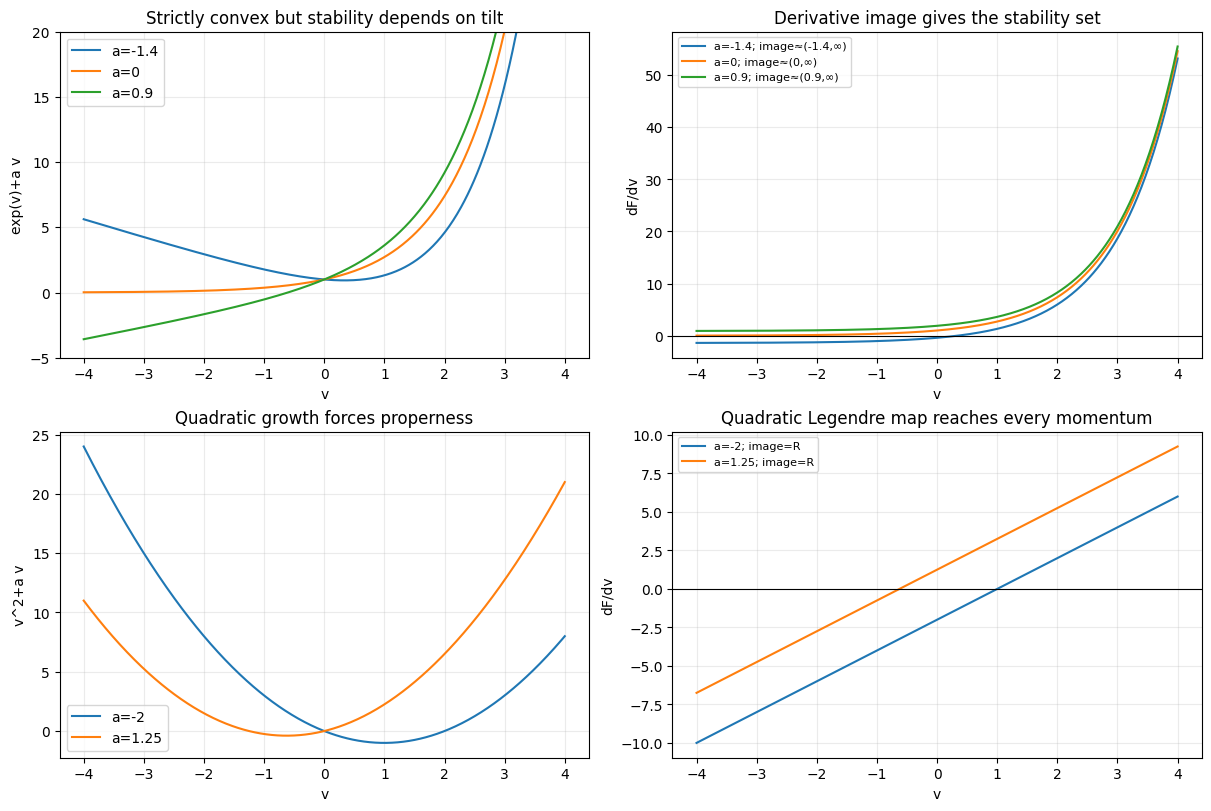

{'exp_second_derivative_min_on_sample': 0.01831563888873418,
 'quadratic_second_derivative': 2.0,
 'exp_derivative_images': {'-1.4': '(-1.4, infinity)',
  '0.0': '(0.0, infinity)',
  '0.9': '(0.9, infinity)'},
 'quadratic_derivative_image': 'all real momenta',
 'lecture_point': 'strict convexity is local; stability and S_F record global minimizers after tilting'}

In [3]:
v = np.linspace(-4, 4, 600)
exp_params = [-1.4, 0.0, 0.9]
quad_params = [-2.0, 1.25]

fig, axs = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

for a in exp_params:
    F = np.exp(v) + a * v
    dF = np.exp(v) + a
    axs[0, 0].plot(v, F, label=f"a={a:g}")
    axs[0, 1].plot(v, dF, label=f"a={a:g}; image≈({a:g},∞)")
axs[0, 0].set_title("Strictly convex but stability depends on tilt")
axs[0, 0].set_xlabel("v")
axs[0, 0].set_ylabel("exp(v)+a v")
axs[0, 0].set_ylim(-5, 20)
axs[0, 0].legend()
axs[0, 0].grid(alpha=0.25)
axs[0, 1].set_title("Derivative image gives the stability set")
axs[0, 1].set_xlabel("v")
axs[0, 1].set_ylabel("dF/dv")
axs[0, 1].axhline(0, color="black", lw=0.8)
axs[0, 1].legend(fontsize=8)
axs[0, 1].grid(alpha=0.25)

for a in quad_params:
    F = v**2 + a * v
    dF = 2 * v + a
    axs[1, 0].plot(v, F, label=f"a={a:g}")
    axs[1, 1].plot(v, dF, label=f"a={a:g}; image=R")
axs[1, 0].set_title("Quadratic growth forces properness")
axs[1, 0].set_xlabel("v")
axs[1, 0].set_ylabel("v^2+a v")
axs[1, 0].legend()
axs[1, 0].grid(alpha=0.25)
axs[1, 1].set_title("Quadratic Legendre map reaches every momentum")
axs[1, 1].set_xlabel("v")
axs[1, 1].set_ylabel("dF/dv")
axs[1, 1].axhline(0, color="black", lw=0.8)
axs[1, 1].legend(fontsize=8)
axs[1, 1].grid(alpha=0.25)

stability_png = FIGURE_DIR / "20-convexity-stability-ledger.png"
fig.savefig(stability_png, dpi=170, bbox_inches="tight")
plt.show()

stability_checks = {
    "exp_second_derivative_min_on_sample": float(np.exp(v).min()),
    "quadratic_second_derivative": 2.0,
    "exp_derivative_images": {str(a): f"({a}, infinity)" for a in exp_params},
    "quadratic_derivative_image": "all real momenta",
    "lecture_point": "strict convexity is local; stability and S_F record global minimizers after tilting",
}
stability_checks

## 2. The Legendre Transform And The Dual Function

For a stable strictly convex function, the gradient map is not just locally invertible; it is a diffeomorphism onto the stability set. The dual function can be computed by minimizing the tilted expression `F(v)-ell v`. In one dimension, the minimizer is the velocity satisfying `ell=F'(v)`.

The next model uses

\[
F(v)=\frac14 v^4 + \frac12 v^2, \qquad L_F(v)=v^3+v.
\]

Its gradient is strictly increasing and onto, so `S_F=R`. The heatmap shows the Young/Fenchel gap. The gap is nonnegative everywhere and vanishes precisely along the equality curve `ell=F'(v)`.

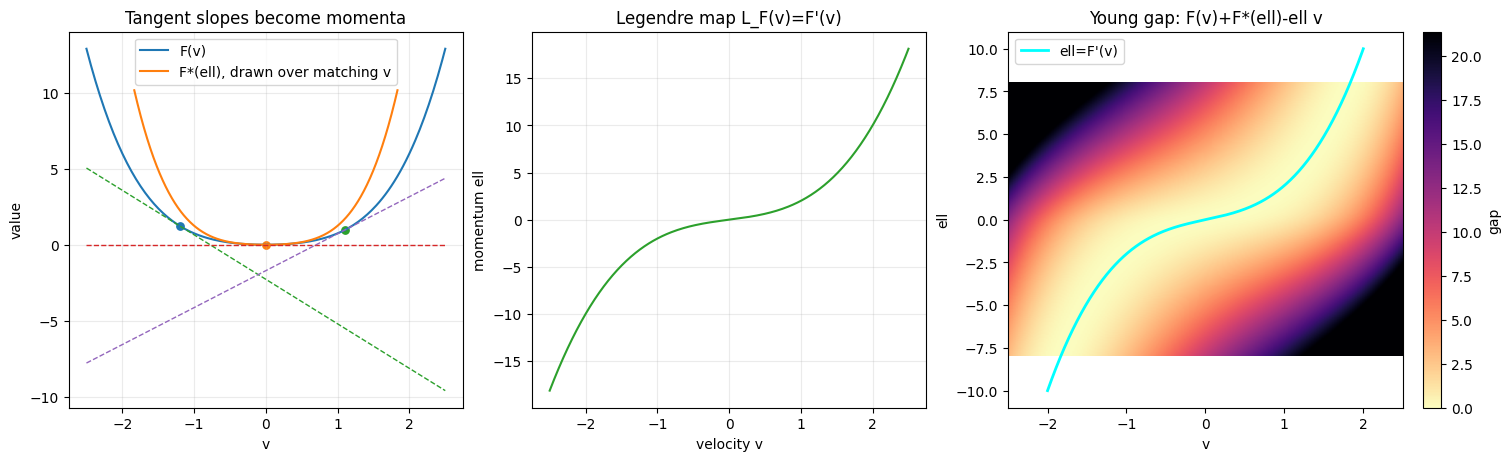

{'model': 'F(v)=v^4/4+v^2/2',
 'hessian_min_on_R_formula': '3 v^2 + 1 >= 1',
 'sampled_hessian_min': 1.0003282505558375,
 'sampled_young_gap_min': 6.243494926394533e-06,
 'sampled_young_gap_max': 43.052470102592366,
 'max_equality_curve_residual': 1.7763568394002505e-15,
 'gradient_monotone_on_sample': True}

In [4]:
def F(v):
    return 0.25 * v**4 + 0.5 * v**2


def dF(v):
    return v**3 + v


def ddF(v):
    return 3 * v**2 + 1


def inv_dF(ell):
    # dF is strictly increasing and spans R; this bracket is ample for plotted momenta.
    return brentq(lambda z: dF(z) - ell, -20, 20)

ells = np.linspace(-8, 8, 401)
v_dual = np.array([inv_dF(ell) for ell in ells])
Fstar = ells * v_dual - F(v_dual)

V = np.linspace(-2.5, 2.5, 240)
E = np.linspace(-8, 8, 260)
VV, EE = np.meshgrid(V, E)
Vstar_grid = np.interp(EE, ells, Fstar)
gap = F(VV) + Vstar_grid - EE * VV

equality_v = np.linspace(-2, 2, 300)
equality_ell = dF(equality_v)

fig, axs = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
axs[0].plot(V, F(V), label="F(v)")
axs[0].plot(v_dual, Fstar, label="F*(ell), drawn over matching v")
for vv in [-1.2, 0.0, 1.1]:
    ell = dF(vv)
    tangent = F(vv) + ell * (V - vv)
    axs[0].plot(V, tangent, "--", lw=1)
    axs[0].scatter([vv], [F(vv)], s=28)
axs[0].set_title("Tangent slopes become momenta")
axs[0].set_xlabel("v")
axs[0].set_ylabel("value")
axs[0].legend()
axs[0].grid(alpha=0.25)

axs[1].plot(V, dF(V), color="tab:green")
axs[1].set_title("Legendre map L_F(v)=F'(v)")
axs[1].set_xlabel("velocity v")
axs[1].set_ylabel("momentum ell")
axs[1].grid(alpha=0.25)

im = axs[2].imshow(
    gap,
    extent=[V.min(), V.max(), E.min(), E.max()],
    origin="lower",
    aspect="auto",
    cmap="magma_r",
    vmin=0,
    vmax=np.percentile(gap, 92),
)
axs[2].plot(equality_v, equality_ell, color="cyan", lw=2, label="ell=F'(v)")
axs[2].set_title("Young gap: F(v)+F*(ell)-ell v")
axs[2].set_xlabel("v")
axs[2].set_ylabel("ell")
axs[2].legend(loc="upper left")
fig.colorbar(im, ax=axs[2], label="gap")

duality_png = FIGURE_DIR / "20-legendre-duality-young-gap.png"
fig.savefig(duality_png, dpi=170, bbox_inches="tight")
plt.show()

equality_residual = np.max(np.abs(F(equality_v) + (dF(equality_v) * equality_v - F(equality_v)) - dF(equality_v) * equality_v))
duality_checks = {
    "model": "F(v)=v^4/4+v^2/2",
    "hessian_min_on_R_formula": "3 v^2 + 1 >= 1",
    "sampled_hessian_min": float(ddF(V).min()),
    "sampled_young_gap_min": float(gap.min()),
    "sampled_young_gap_max": float(gap.max()),
    "max_equality_curve_residual": float(equality_residual),
    "gradient_monotone_on_sample": bool(np.all(np.diff(dF(V)) > 0)),
}
duality_checks

## 3. Proof Route: Where The Identities Enter

The Legendre transform is a theorem route, not a single formula. Positive Hessian gives the local inverse function theorem. Stability tells us which tilted functions have global minimizers. The dual function packages the minimum value. In the variational application, the same construction is applied fiber by fiber on `TM`, replacing velocity coordinates by momentum coordinates.

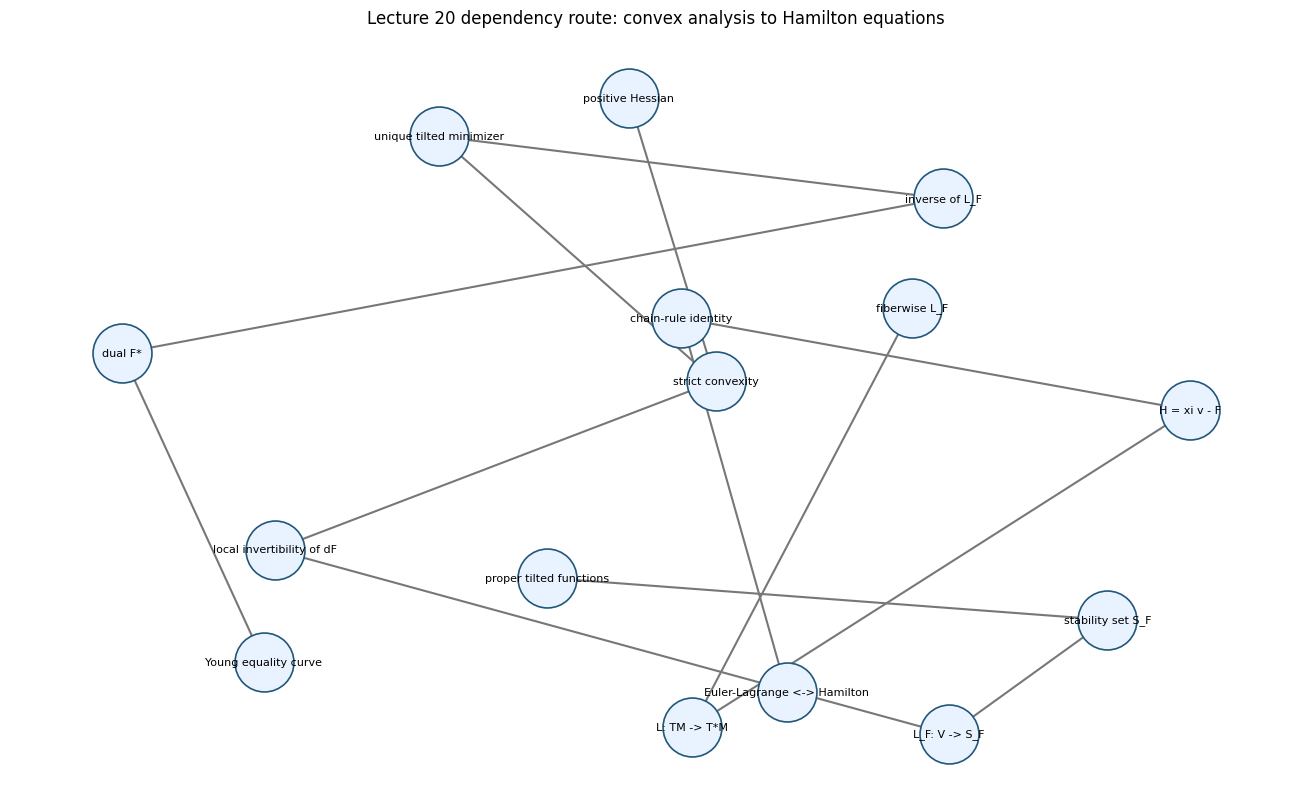

{'node_count': 15,
 'edge_count': 13,
 'is_directed_acyclic_graph': True,
 'isolated_nodes': []}

In [5]:
G = nx.DiGraph()
edges = [
    ("positive Hessian", "strict convexity"),
    ("strict convexity", "local invertibility of dF"),
    ("proper tilted functions", "stability set S_F"),
    ("strict convexity", "unique tilted minimizer"),
    ("unique tilted minimizer", "inverse of L_F"),
    ("stability set S_F", "L_F: V -> S_F"),
    ("local invertibility of dF", "L_F: V -> S_F"),
    ("inverse of L_F", "dual F*"),
    ("dual F*", "Young equality curve"),
    ("fiberwise L_F", "L: TM -> T*M"),
    ("L: TM -> T*M", "H = xi v - F"),
    ("chain-rule identity", "Euler-Lagrange <-> Hamilton"),
    ("H = xi v - F", "chain-rule identity"),
]
G.add_edges_from(edges)
pos = nx.spring_layout(G, seed=20, k=1.4)

fig, ax = plt.subplots(figsize=(13, 8), constrained_layout=True)
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=14, width=1.5, edge_color="#777777")
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=1800, node_color="#e8f3ff", edgecolors="#22577a", linewidths=1.2)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
ax.set_title("Lecture 20 dependency route: convex analysis to Hamilton equations")
ax.axis("off")
route_png = FIGURE_DIR / "20-legendre-proof-route.png"
fig.savefig(route_png, dpi=170, bbox_inches="tight")
plt.show()

route_checks = {
    "node_count": G.number_of_nodes(),
    "edge_count": G.number_of_edges(),
    "is_directed_acyclic_graph": nx.is_directed_acyclic_graph(G),
    "isolated_nodes": list(nx.isolates(G)),
}
route_checks

## 4. Fiberwise Legendre Transform In A Variational Problem

For a function `F:TM -> R`, Lecture 20 applies the Legendre transform on each tangent space. A simple mechanical model is

\[
F(x,v)=\frac12 m(x)v^2-U(x), \qquad m(x)=1+0.4\cos x, \qquad U(x)=1-\cos x.
\]

The momentum is `xi = partial F/partial v = m(x)v`, so the fiberwise Legendre transform sends `(x,v)` to `(x,xi)`. The Hamiltonian dual is

\[
H(x,\xi)=\frac{\xi^2}{2m(x)}+U(x).
\]

The surface artifact lets you compare the Lagrangian and Hamiltonian pictures. The symbolic check below verifies the two chain-rule identities that make the coordinate proof work.

In [6]:
x_grid = np.linspace(-math.pi, math.pi, 80)
v_grid = np.linspace(-2.2, 2.2, 80)
xi_grid = np.linspace(-2.2, 2.2, 80)
Xv, Vv = np.meshgrid(x_grid, v_grid)
Xxi, XI = np.meshgrid(x_grid, xi_grid)
M = 1 + 0.4 * np.cos(Xv)
U = 1 - np.cos(Xv)
L_surface = 0.5 * M * Vv**2 - U
M_xi = 1 + 0.4 * np.cos(Xxi)
U_xi = 1 - np.cos(Xxi)
H_surface = XI**2 / (2 * M_xi) + U_xi

fig = go.Figure()
fig.add_trace(go.Surface(x=Xv, y=Vv, z=L_surface, colorscale="Viridis", opacity=0.92, name="F(x,v)", showscale=False))
fig.add_trace(go.Surface(x=Xxi, y=XI + 5.2, z=H_surface, colorscale="Cividis", opacity=0.92, name="H(x,xi)", showscale=False))
fig.add_trace(go.Scatter3d(x=x_grid, y=5.2 + np.zeros_like(x_grid), z=(1-np.cos(x_grid)), mode="lines", line=dict(color="black", width=5), name="zero momentum energy"))
fig.update_layout(
    title="Fiberwise Legendre transform: Lagrangian surface and Hamiltonian surface",
    scene=dict(
        xaxis_title="position x",
        yaxis_title="left: velocity v, right: momentum xi shifted",
        zaxis_title="value",
        camera=dict(eye=dict(x=1.55, y=-1.75, z=1.15)),
    ),
    margin=dict(l=0, r=0, b=0, t=48),
    height=620,
)
html_path = HTML_DIR / "20-fiberwise-legendre-hamiltonian.html"
fig.write_html(html_path, include_plotlyjs="cdn", full_html=True)
display_artifact(html_path, width="100%", height=520)

In [7]:
x, v_sym, xi = sp.symbols("x v xi", real=True)
m = 1 + sp.Rational(2, 5) * sp.cos(x)
U = 1 - sp.cos(x)
F_sym = sp.Rational(1, 2) * m * v_sym**2 - U
momentum = sp.diff(F_sym, v_sym)
v_from_xi = xi / m
H_sym = sp.simplify(xi * v_from_xi - F_sym.subs(v_sym, v_from_xi))

residual_H_xi = sp.simplify(sp.diff(H_sym, xi) - v_from_xi)
residual_chain = sp.simplify(sp.diff(H_sym, x) + sp.diff(F_sym, x).subs(v_sym, v_from_xi))
hessian_v = sp.simplify(sp.diff(F_sym, v_sym, 2))

symbolic_checks = {
    "momentum_xi": str(momentum),
    "hamiltonian_H": str(H_sym),
    "hessian_in_velocity": str(hessian_v),
    "residual_dH_dxi_minus_v": str(residual_H_xi),
    "residual_dH_dx_plus_dF_dx": str(residual_chain),
    "mass_min": float(min(1 + 0.4 * np.cos(x_grid))),
}
assert residual_H_xi == 0
assert residual_chain == 0
assert symbolic_checks["mass_min"] > 0
symbolic_checks

{'momentum_xi': '2*v*(cos(x)/5 + 1/2)',
 'hamiltonian_H': '(5*xi**2 - 4*cos(x)**2 - 6*cos(x) + 10)/(2*(2*cos(x) + 5))',
 'hessian_in_velocity': '2*cos(x)/5 + 1',
 'residual_dH_dxi_minus_v': '0',
 'residual_dH_dx_plus_dF_dx': '0',
 'mass_min': 0.6}

## 5. Inline Artifact Review

The notebook generated every artifact below from the code above. Inspect them in order: first the hypothesis route, then the stability warning, then the duality residual, then the fiberwise variational model.

lecture dependency route -> artifacts\lecture-20\figures\20-legendre-proof-route.png


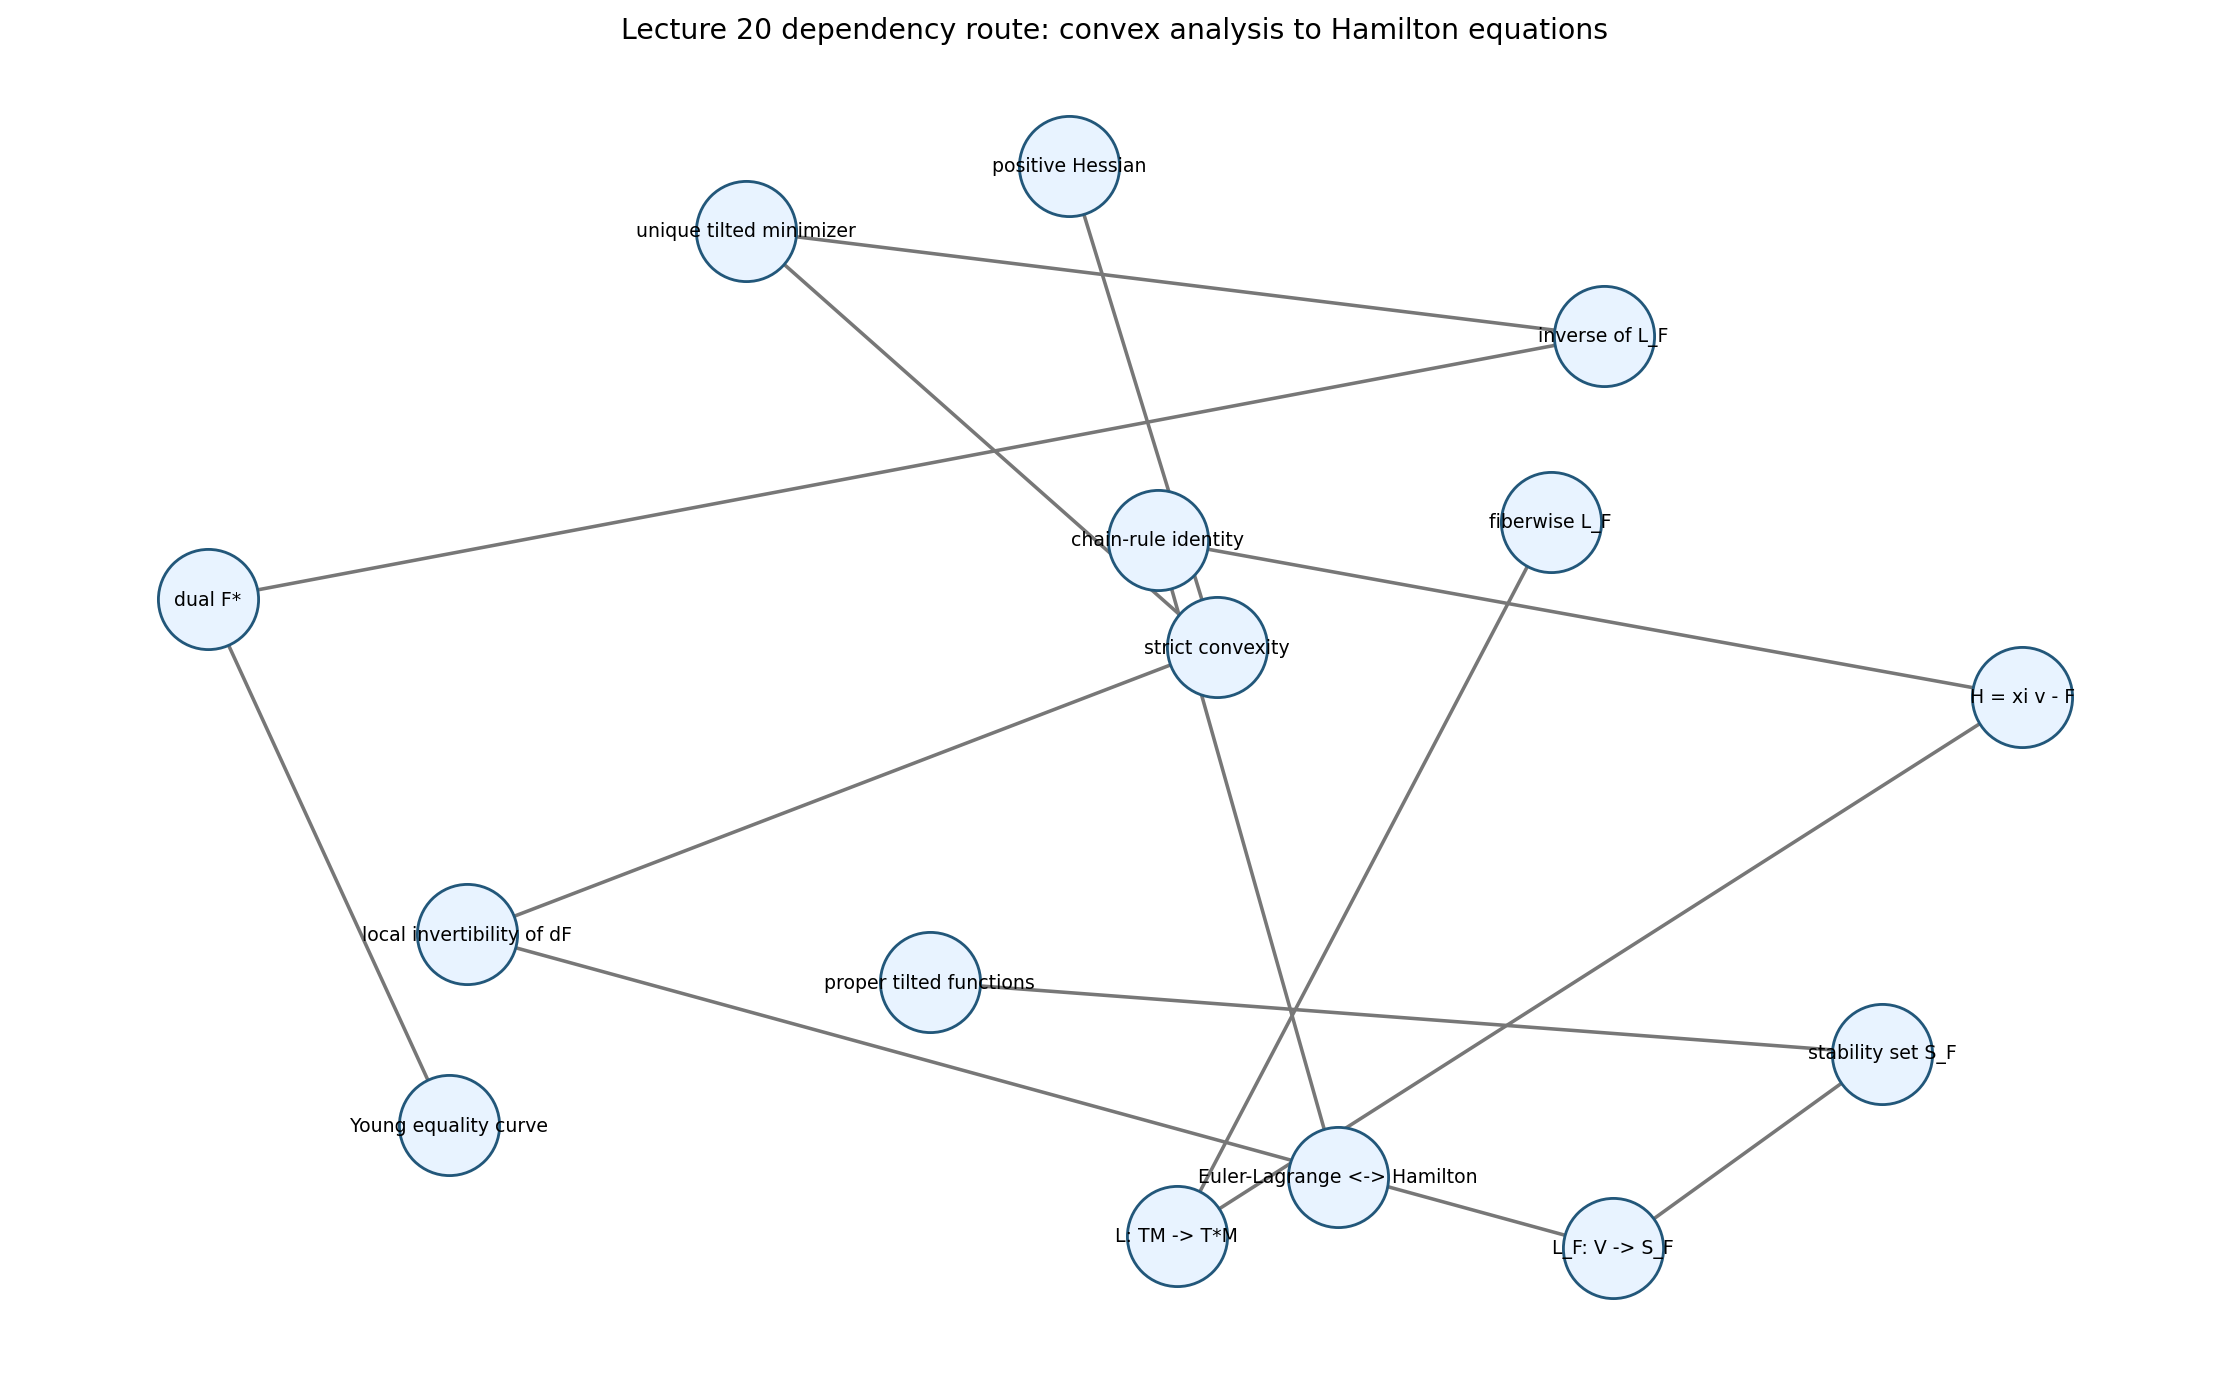

strict convexity versus stability -> artifacts\lecture-20\figures\20-convexity-stability-ledger.png


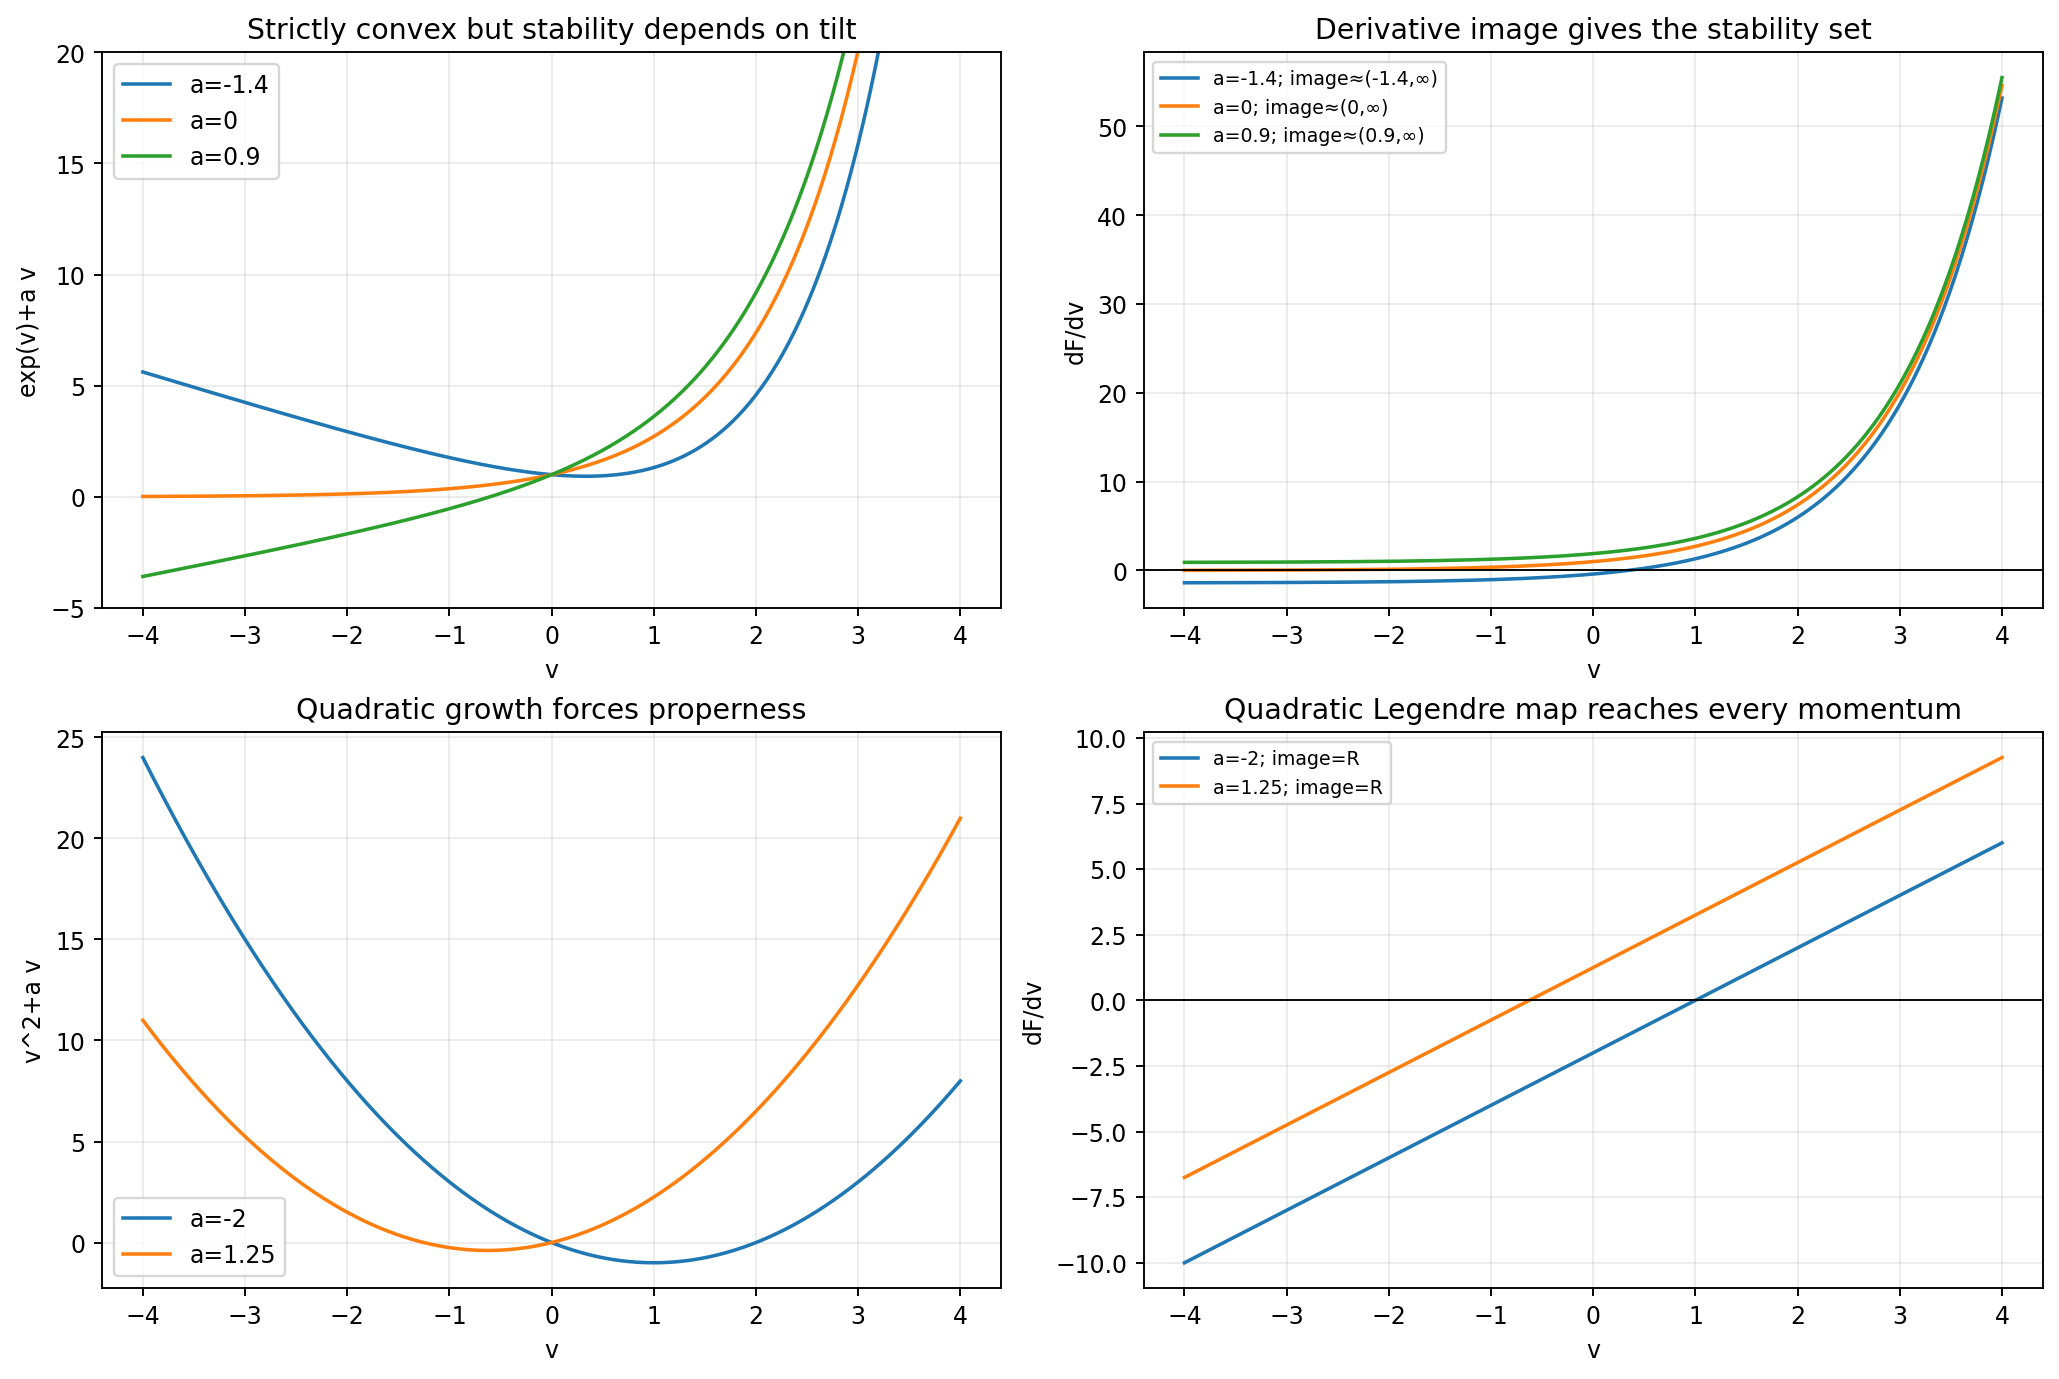

Legendre duality and Young gap -> artifacts\lecture-20\figures\20-legendre-duality-young-gap.png


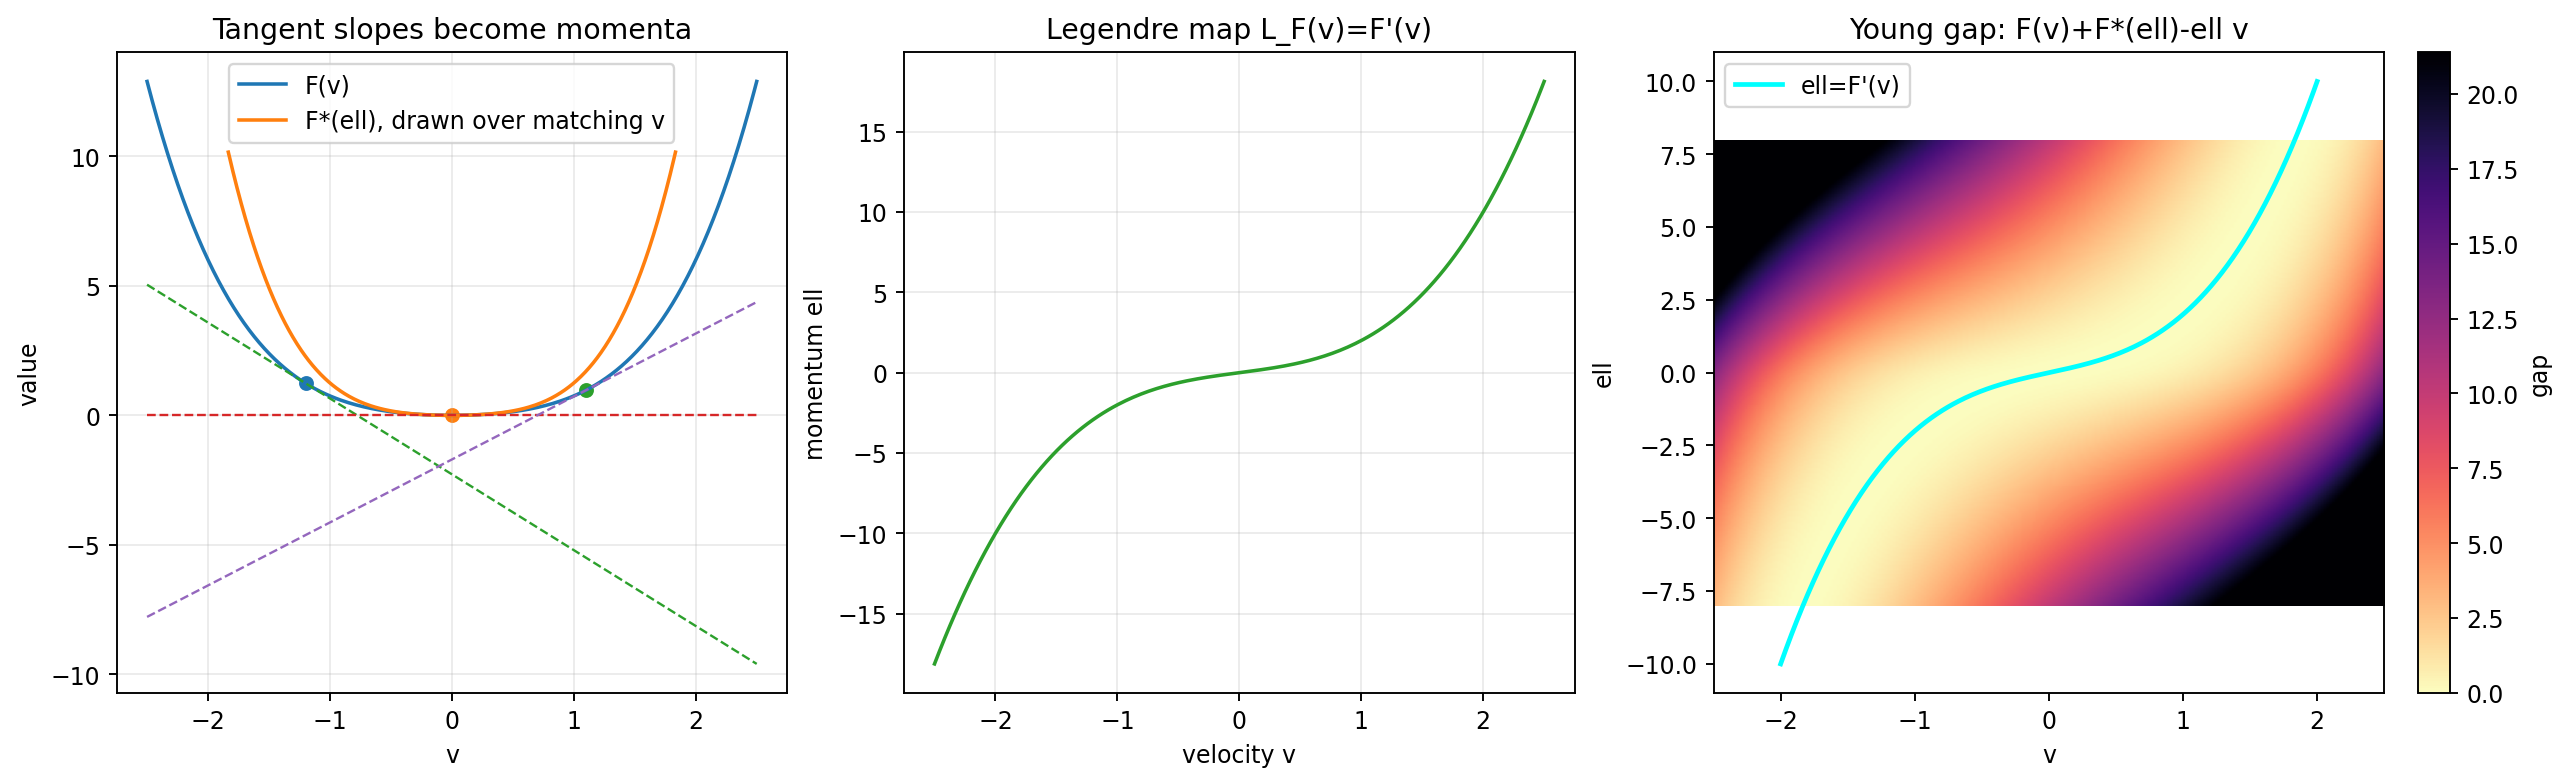

fiberwise Lagrangian to Hamiltonian transform -> artifacts\lecture-20\interactive\20-fiberwise-legendre-hamiltonian.html


In [8]:
for item in storyboard["visual_sequence"]:
    path = BOOK_ROOT / item["artifact"]
    print(f"{item['concept']} -> {path.relative_to(BOOK_ROOT)}")
    display_artifact(path, width="100%" if path.suffix == ".html" else 780, height=500 if path.suffix == ".html" else None)

## Takeaways And Small Exploration

The Legendre transform records how a convex function sees its tangent slopes. Strict convexity makes the slope map locally faithful; stability describes which slopes come from global tilted minima; the dual function records those minimum values in momentum coordinates.

In mechanics, this is the coordinate bridge from a Lagrangian on `TM` to a Hamiltonian on `T*M`. The bridge is not formal symbol swapping: it depends on fiberwise convexity so that velocity can be recovered from momentum. Try changing the mass model to one that can vanish or become negative. The final checks should fail because the velocity Hessian no longer certifies a valid fiberwise Legendre transform.

In [9]:
invariants = {
    "source_span": source_span,
    "stability_checks": stability_checks,
    "duality_checks": duality_checks,
    "route_checks": route_checks,
    "symbolic_checks": symbolic_checks,
}
save_json(invariants, CHECK_DIR / "legendre-invariants.json")

artifact_paths = []
for group in storyboard["artifact_plan"].values():
    artifact_paths.extend(group)

final_sanity = {
    "passed": True,
    "lecture": 20,
    "source_pages_actually_read": source_span["physical_pdf_pages_read"],
    "artifacts": artifact_paths,
    "checks": {
        "positive_exp_second_derivative": stability_checks["exp_second_derivative_min_on_sample"] > 0,
        "positive_quartic_hessian": duality_checks["sampled_hessian_min"] >= 1.0,
        "young_gap_nonnegative_with_tolerance": duality_checks["sampled_young_gap_min"] >= -1e-8,
        "young_equality_curve_small_residual": duality_checks["max_equality_curve_residual"] < 2e-3,
        "proof_route_has_no_isolates": route_checks["isolated_nodes"] == [],
        "proof_route_is_dag": route_checks["is_directed_acyclic_graph"] is True,
        "symbolic_hamilton_identity_dH_dxi": symbolic_checks["residual_dH_dxi_minus_v"] == "0",
        "symbolic_hamilton_identity_dH_dx": symbolic_checks["residual_dH_dx_plus_dF_dx"] == "0",
        "fiber_hessian_positive": symbolic_checks["mass_min"] > 0,
    },
}
final_sanity["assertions"] = dict(final_sanity["checks"])
save_json(final_sanity, CHECK_DIR / "final-sanity.json")

for relative in artifact_paths:
    path = BOOK_ROOT / relative
    assert path.exists(), f"missing artifact: {relative}"
    assert path.stat().st_size > 500, f"artifact too small or empty: {relative}"
for name, ok in final_sanity["checks"].items():
    assert ok, name

print(json.dumps({
    "checked_artifact_count": len(artifact_paths),
    "all_checks_passed": True,
    "source_pages": final_sanity["source_pages_actually_read"],
}, indent=2))

{
  "checked_artifact_count": 8,
  "all_checks_passed": true,
  "source_pages": "128-135 for boundary check; Lecture 20 content on 129-134"
}
